## Name: Neeraj Kumar
## Bits ID: 2025AD05063
## Machine Learning Assignment 2: Bank Marketing Classification

**Objective:** Predict whether a client will subscribe to a term deposit based on bank marketing campaign data.

**Dataset:** Bank Marketing Dataset from UCI Machine Learning Repository

**Models to implement:**
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbor Classifier
4. Naive Bayes (Gaussian)
5. Random Forest (Ensemble)

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, matthews_corrcoef,
                             confusion_matrix, classification_report)
import joblib
import warnings
warnings.filterwarnings('ignore')

## Step 1: Load the Dataset

In [2]:
#the bank marketing dataset
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Step 2: Exploratory Data Analysis

In [3]:
#checking basic info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
#statistical summary
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
#checking for missing values
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [6]:
#target variable distribution
print('Target variable (y) distribution:')
print(df['y'].value_counts())
print()
print('Percentage:')
print(df['y'].value_counts(normalize=True) * 100)

Target variable (y) distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Percentage:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


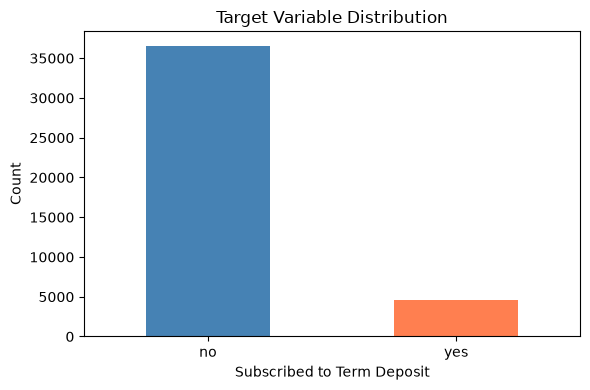

In [7]:
#visualize target distribution
plt.figure(figsize=(6, 4))
df['y'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Target Variable Distribution')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
#checking column types
print('Categorical columns:')
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)
print()
print('Numerical columns:')
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Numerical columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


## Step 3: Data Preprocessing

In [9]:
#make a copy for processing
data = df.copy()

#encode categorical variables using LabelEncoder
label_encoders = {}
categorical_columns = data.select_dtypes(include='object').columns

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f'{col}: {list(le.classes_)}')

print('\nEncoding done!')
data.head()

job: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']
marital: ['divorced', 'married', 'single', 'unknown']
education: ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']
default: ['no', 'unknown', 'yes']
housing: ['no', 'unknown', 'yes']
loan: ['no', 'unknown', 'yes']
contact: ['cellular', 'telephone']
month: ['apr', 'aug', 'dec', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
day_of_week: ['fri', 'mon', 'thu', 'tue', 'wed']
poutcome: ['failure', 'nonexistent', 'success']
y: ['no', 'yes']

Encoding done!


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [10]:
#separate features and target
X = data.drop('y', axis=1)
y = data['y']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('Number of features:', X.shape[1])

Features shape: (41188, 20)
Target shape: (41188,)
Number of features: 20


In [11]:
#split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])

Training set size: 32950
Test set size: 8238


In [12]:
#scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaling done!')

Scaling done!


In [13]:
#save test data as csv for streamlit app
test_data = X_test.copy()
test_data['y'] = y_test.values
test_data.to_csv('../test_data.csv', index=False)
print('Test data saved to test_data.csv')
print('Test data shape:', test_data.shape)

Test data saved to test_data.csv
Test data shape: (8238, 21)


## Step 4: Helper Function for Evaluation

In [14]:
#function to calculate all evaluation metrics
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    print(f'\n--- {model_name} ---')
    print(f'Accuracy:  {accuracy:.4f}')
    print(f'AUC Score: {auc:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'F1 Score:  {f1:.4f}')
    print(f'MCC Score: {mcc:.4f}')
    
    #confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    return {
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'AUC': round(auc, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1': round(f1, 4),
        'MCC': round(mcc, 4)
    }

## Step 5: Model 1 - Logistic Regression


--- Logistic Regression ---
Accuracy:  0.9139
AUC Score: 0.9370
Precision: 0.7002
Recall:    0.4127
F1 Score:  0.5193
MCC Score: 0.4956


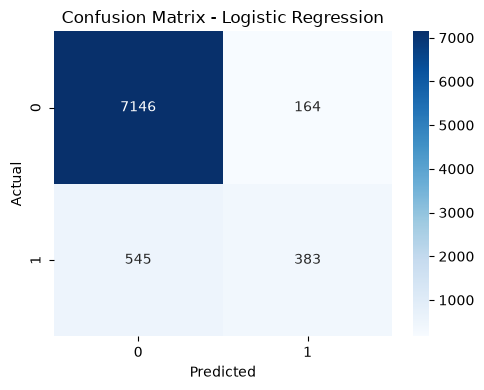

In [15]:
#training logistic regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_results = evaluate_model(lr_model, X_test_scaled, y_test, 'Logistic Regression')

## Step 6: Model 2 - Decision Tree Classifier


--- Decision Tree ---
Accuracy:  0.8956
AUC Score: 0.7535
Precision: 0.5343
Recall:    0.5700
F1 Score:  0.5516
MCC Score: 0.4929


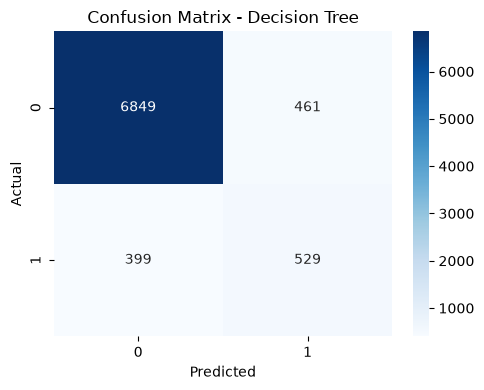

In [16]:
#training decision tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_results = evaluate_model(dt_model, X_test_scaled, y_test, 'Decision Tree')

## Step 7: Model 3 - K-Nearest Neighbor Classifier


--- KNN ---
Accuracy:  0.9053
AUC Score: 0.8617
Precision: 0.6267
Recall:    0.3944
F1 Score:  0.4841
MCC Score: 0.4491


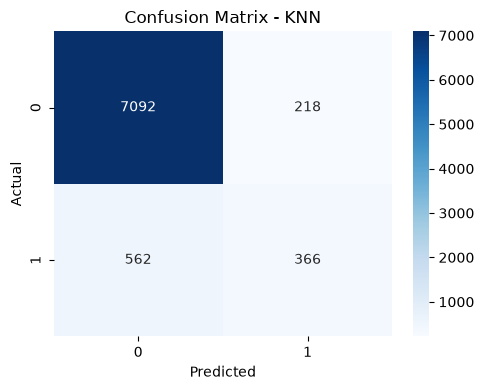

In [17]:
#training KNN with k=5
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_results = evaluate_model(knn_model, X_test_scaled, y_test, 'KNN')

## Step 8: Model 4 - Naive Bayes (Gaussian)


--- Naive Bayes ---
Accuracy:  0.8536
AUC Score: 0.8606
Precision: 0.4024
Recall:    0.6175
F1 Score:  0.4872
MCC Score: 0.4189


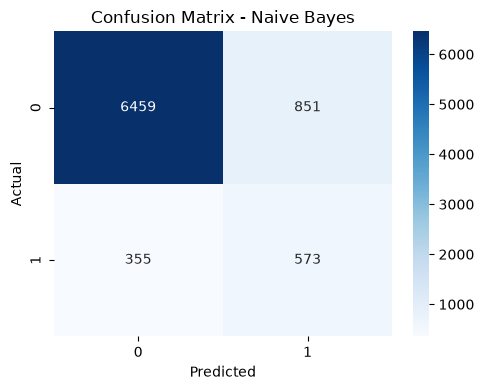

In [18]:
#training Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

nb_results = evaluate_model(nb_model, X_test_scaled, y_test, 'Naive Bayes')

## Step 9: Model 5 - Random Forest (Ensemble)


--- Random Forest (Ensemble) ---
Accuracy:  0.9205
AUC Score: 0.9491
Precision: 0.6898
Recall:    0.5345
F1 Score:  0.6023
MCC Score: 0.5645


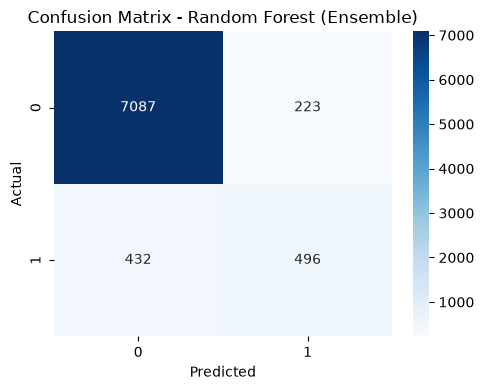

In [19]:
#training Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_results = evaluate_model(rf_model, X_test_scaled, y_test, 'Random Forest (Ensemble)')

## Step 10: Comparison Table

In [20]:
#creating comparison table
all_results = [lr_results, dt_results, knn_results, nb_results, rf_results]
results_df = pd.DataFrame(all_results)
results_df.set_index('Model', inplace=True)

print('\n========== Model Comparison Table ==========')
print(results_df.to_string())


========== Model Comparison Table ==========
                          Accuracy     AUC  Precision  Recall      F1     MCC
Model                                                                        
Logistic Regression         0.9139  0.9370     0.7002  0.4127  0.5193  0.4956
Decision Tree               0.8956  0.7535     0.5343  0.5700  0.5516  0.4929
KNN                         0.9053  0.8617     0.6267  0.3944  0.4841  0.4491
Naive Bayes                 0.8536  0.8606     0.4024  0.6175  0.4872  0.4189
Random Forest (Ensemble)    0.9205  0.9491     0.6898  0.5345  0.6023  0.5645


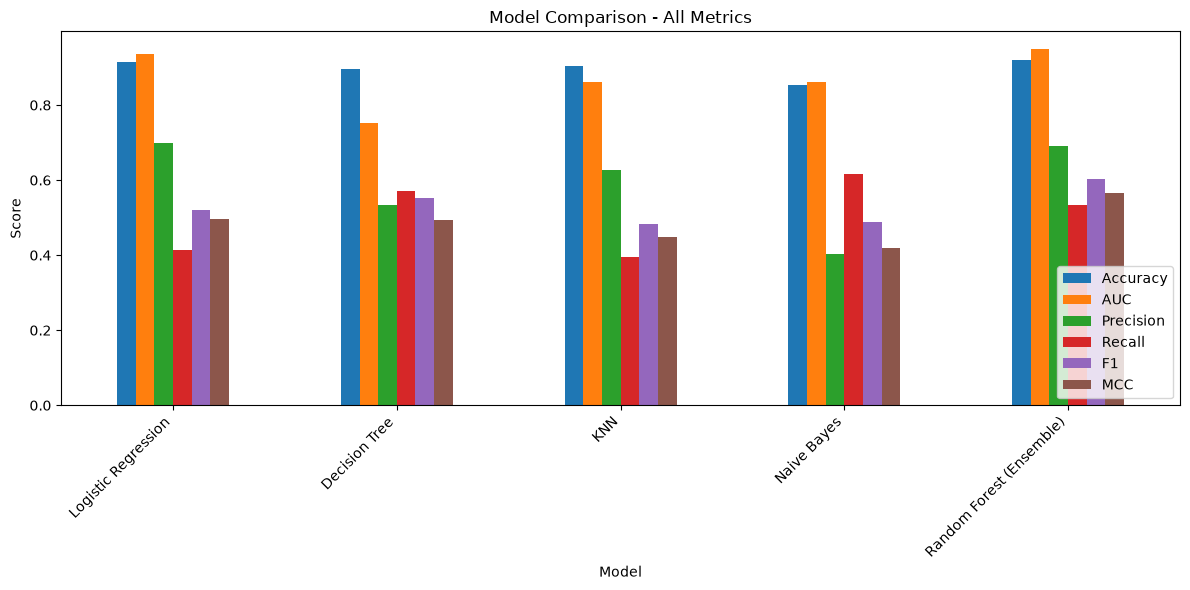

In [21]:
#visualize comparison
results_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Comparison - All Metrics')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 11: Save Models

In [22]:
#saving all trained models
joblib.dump(lr_model, 'logistic_regression.pkl')
joblib.dump(dt_model, 'decision_tree.pkl')
joblib.dump(knn_model, 'knn.pkl')
joblib.dump(nb_model, 'naive_bayes.pkl')
joblib.dump(rf_model, 'random_forest.pkl')

#saving scaler and label encoders for use in streamlit app
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

#save the feature names for reference
joblib.dump(list(X.columns), 'feature_names.pkl')

print('All models saved successfully!')
print('Files saved:')
print('  - logistic_regression.pkl')
print('  - decision_tree.pkl')
print('  - knn.pkl')
print('  - naive_bayes.pkl')
print('  - random_forest.pkl')
print('  - scaler.pkl')
print('  - label_encoders.pkl')
print('  - feature_names.pkl')

All models saved successfully!
Files saved:
  - logistic_regression.pkl
  - decision_tree.pkl
  - knn.pkl
  - naive_bayes.pkl
  - random_forest.pkl
  - scaler.pkl
  - label_encoders.pkl
  - feature_names.pkl
